In [2]:
!pip install astropy
!pip install photutils 
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as const
from astropy.io import fits
import scipy 
import urllib.request
import os 
from scipy import optimize
import photutils.detection as detect

In [3]:
NGC2660_555_fits = "hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits = "hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"
NGC2660_fits = "hst_10634_03_acs_wfc_total_j9dm03.fits"
NGC2660_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&dataset=hst_10634_03_acs_wfc_total_j9dm03"
NGC2660_555_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f555w_j9dm03_drc.fits"
NGC2660_814_fits_url = "https://hla.stsci.edu/cgi-bin/getdata.cgi?config=ops&download=1&dataset=hst_10634_03_acs_wfc_total_j9dm03&filename=hst_10634_03_acs_wfc_f814w_j9dm03_drc.fits"

if not os.path.exists(NGC2660_814_fits) & os.path.exists(NGC2660_555_fits):
        try:
            urllib.request.urlretrieve(NGC2660_814_fits_url, NGC2660_814_fits)
            print(f"Downloaded {NGC2660_814_fits}")
            urllib.request.urlretrieve(NGC2660_555_fits_url, NGC2660_555_fits)
            print(f"Downloaded {NGC2660_555_fits}")
        except Exception as e:
            print("Error Downloading File")
            NGC2660_555_fits = None
            NGC2660_814_fits = None

In [4]:
from matplotlib.colors import LogNorm

bands = [NGC2660_555_fits, NGC2660_814_fits]
image_data = []
for b in bands:
    with fits.open(b) as HDUList:
        image_data.append(HDUList[1].data) #reads the data from the SCI section of the fits file
        HDUList.close()
image_555, image_814 = image_data

sigma = 3
fwhm = 2.355 * sigma


In [5]:
clipped_data_555 = image_555.copy()
for i in range(5):
    mean = np.nanmean(clipped_data_555)
    std = np.nanstd(clipped_data_555)
    mask = np.abs(clipped_data_555 - mean) <= 3 * std
    clipped_data = clipped_data_555[mask]
    background_mean_555 = np.mean(clipped_data)
import array



clipped_data_814 = image_814.copy()
for i in range(5):
    mean = np.nanmean(clipped_data_814)
    std = np.nanstd(clipped_data_814)
    mask = np.abs(clipped_data_814 - mean) <= 3 * std
    clipped_data = clipped_data_814[mask]
    background_mean_814 = np.mean(clipped_data)




#gaussian_PSF

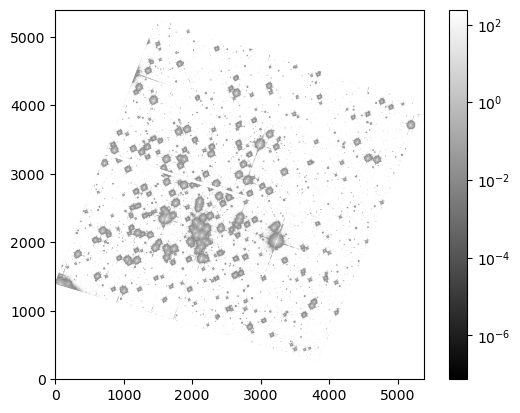

(array([6.220000e+02, 1.470100e+04, 6.970070e+05, 6.546433e+06,
        6.149396e+06, 1.360588e+06, 4.191260e+05, 2.209370e+05,
        1.453760e+05, 1.051600e+05, 8.035400e+04, 6.481100e+04,
        5.367200e+04, 4.488800e+04, 3.758500e+04, 3.253500e+04,
        2.810000e+04, 2.442800e+04, 2.146900e+04, 1.908600e+04,
        1.674400e+04, 1.511500e+04, 1.332900e+04, 1.196300e+04,
        1.061500e+04, 9.828000e+03, 9.078000e+03, 8.166000e+03,
        7.558000e+03, 7.030000e+03, 6.450000e+03, 5.924000e+03,
        5.632000e+03, 5.145000e+03, 4.856000e+03, 4.717000e+03,
        4.269000e+03, 3.979000e+03, 3.837000e+03, 3.568000e+03,
        3.366000e+03, 3.216000e+03, 3.042000e+03, 3.020000e+03,
        2.826000e+03, 2.620000e+03, 2.511000e+03, 2.406000e+03,
        2.289000e+03, 2.338000e+03]),
 array([-0.1       , -0.083     , -0.066     , -0.049     , -0.032     ,
        -0.015     ,  0.002     ,  0.019     ,  0.036     ,  0.053     ,
         0.07      ,  0.087     ,  0.104     ,  

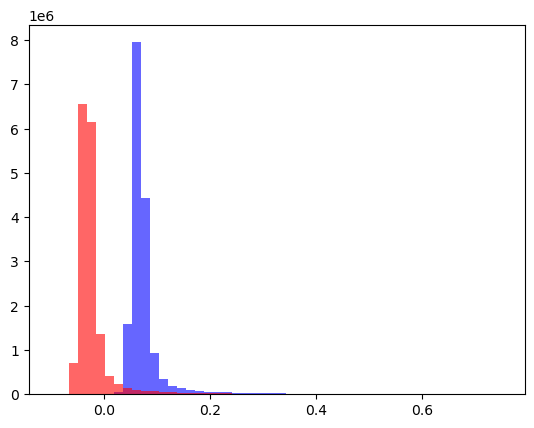

In [6]:
subtracted_image_555 = image_555 - background_mean_555

plt.figure()
plt.imshow(subtracted_image_555, cmap='grey', origin = 'lower', norm=LogNorm())
plt.colorbar(norm=LogNorm())
plt.show()

fig, axes = plt.subplots()
axes.hist(image_555.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
axes.hist(subtracted_image_555.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

0.09751291


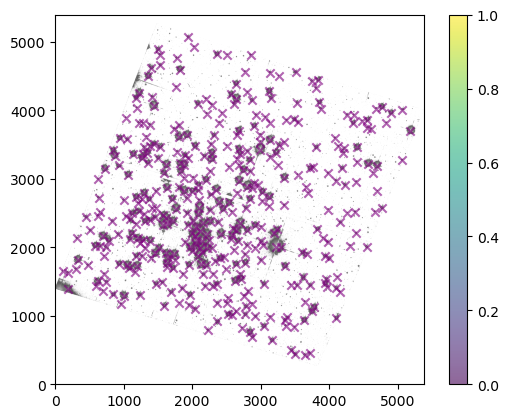

In [9]:
subtracted_image_555 = image_555 - background_mean_555
subtracted_image_814 = image_814 - background_mean_814
print(background_mean_555)
detection_threshold = 500 * background_mean_555

filter = int(np.ceil(fwhm))


detections =  detect.find_peaks(subtracted_image_555, detection_threshold, min_separation=50, border_width=20)
detections_x = detections['x_peak']
detections_y = detections['y_peak']

plt.figure()
plt.imshow(subtracted_image_555, cmap='grey', origin = 'lower', norm=LogNorm(vmin = .0001, vmax=300))
plt.scatter(detections_x, detections_y, color = 'purple', alpha =.6, marker='x', )
plt.colorbar(norm=LogNorm(vmin = .0001, vmax=300))
plt.show()


#axes[2].hist(image_data.flatten(), bins=50, color='blue', range=(-.1, .75), alpha=.6)
#axes[2].hist(subtracted_image.flatten(), bins=50, color='red', range=(-.1, .75), alpha=.6)

In [ ]:
class Star:
    """One star is the coordinates of the center of a star on the image"""
    
    def __init__(self, row, col, name=""):
        self.row = row
        self.col = col
        self.name = name

    def get_row_col(self):
        return (self.row, self.col)

    def value_at(self, image):
        return image[self.row, self.col]

    def cutout(self, image, half_size=8):
        nrows, ncols = image.shape
        r_start = self.row - half_size
        r_end = self.row + half_size + 1
        c_start = self.col - half_size + 1
        c_end = self.col + half_size + 1
        if r_start < 0:
            r_start = 0
        if c_start < 0: 
            c_start = 0
        if r_end > nrows:
            r_end = nrows
        if c_end > ncols:
            c_end = ncols
        return image[r_start:r_end, c_start:c_end]


stars = [
    Star(1311, 1231, "1"),
    Star(544, 3297, "2"),
    Star(2910, 4128, "3"),
    Star(4462, 1557, "4"),
    Star(1657, 2605, "5"),
    Star(4064, 1437, "6"),
    Star(2160, 690, "7"),
    Star(4531, 1714, "8"),
    Star(2010, 3225, "9"),
    Star(2710, 1710, "10"),
    Star(4531, 1713, "11"),
    Star(4168, 2647, "12"),
    Star(3565, 3130, "13"),
    Star(3203, 1623, "14")
]


(272,)
[8.5, 8.0, 1.0, np.float32(208.57176), np.float32(0.963423)]
popt [  6.70373678   7.16862549   1.54902856 245.86096246   0.96342301]
(272,)
[8.5, 8.0, 1.0, np.float32(3.2142127), np.float32(-0.021720383)]
popt [ 6.71441445  8.38846381  0.94377958  3.40139777 -0.02172038]
(272,)
[8.5, 8.0, 1.0, np.float32(9.808505), np.float32(-0.0152230635)]
popt [ 7.2192659   8.40688428  0.91804069 10.89186266 -0.01522306]
(272,)
[8.5, 8.0, 1.0, np.float32(9.026221), np.float32(-0.013094347)]
popt [ 7.47219987  7.66851843  0.95287149  9.75878616 -0.01309435]
(272,)
[8.5, 8.0, 1.0, np.float32(27.383919), np.float32(0.024545956)]
popt [6.52921342e+00 7.76909035e+00 9.98514542e-01 3.07986861e+01
 2.45459564e-02]
(272,)
[8.5, 8.0, 1.0, np.float32(162.70038), np.float32(38.748566)]
popt [  6.49168548   5.83870514   4.15006013 216.21609724  38.74856567]
(272,)
[8.5, 8.0, 1.0, np.float32(211.63033), np.float32(9.806332)]
popt [ 10.86691796   9.17947915   3.73083357 213.79408286   9.80633163]
(272,)
[8

C:\Users\siena\AppData\Local\Temp\ipykernel_8364\2200078840.py:45: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(1, 3, figsize=(15, 5))


popt [ 10.87284643   8.65561074   4.60285675 235.91123145  35.84752655]
(272,)
[8.5, 8.0, 1.0, np.float32(112.44133), np.float32(0.32906562)]
popt [  6.48907943   7.83249658   0.98467194 111.15506938   0.32906562]
(272,)
[8.5, 8.0, 1.0, np.float32(6.4153595), np.float32(233.33575)]
popt [  7.68371352   7.85425081  10.         283.98053277 233.33575439]
(272,)
[8.5, 8.0, 1.0, np.float32(206.98013), np.float32(15.991493)]
popt [  7.48665412   8.50338002   3.35086613 251.88329361  15.99149323]
(272,)
[8.5, 8.0, 1.0, np.float32(112.44133), np.float32(0.32906562)]
popt [  7.48914039   7.83250923   0.98433013 111.2239624    0.32906562]
(272,)
[8.5, 8.0, 1.0, np.float32(75.45949), np.float32(131.77322)]
popt [  4.65219154   7.67465614   6.12335976 227.44762406 131.77322388]
(272,)
[8.5, 8.0, 1.0, np.float32(132.0642), np.float32(77.24373)]
popt [  8.66279917   8.71987245   4.81115428 225.29592566  77.24372864]
(272,)
[8.5, 8.0, 1.0, np.float32(66.27254), np.float32(140.39412)]
popt [  8.40715

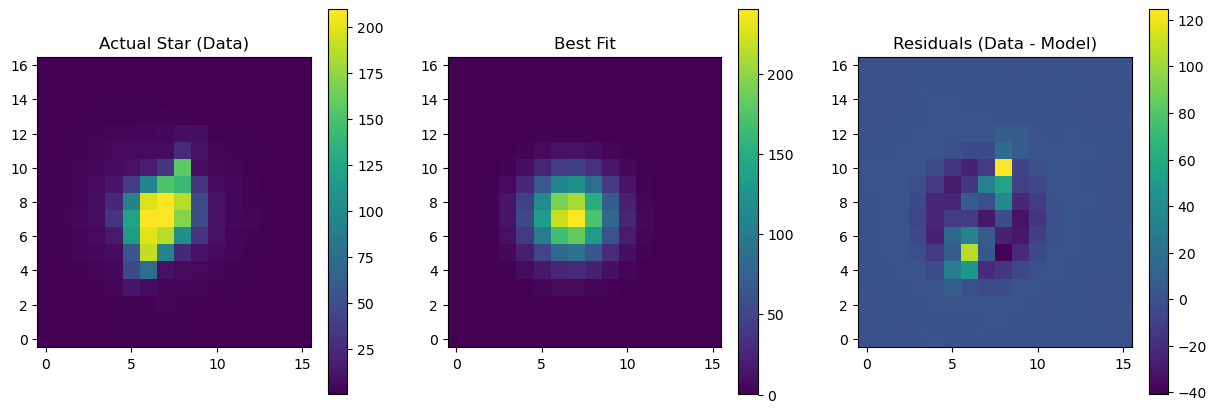

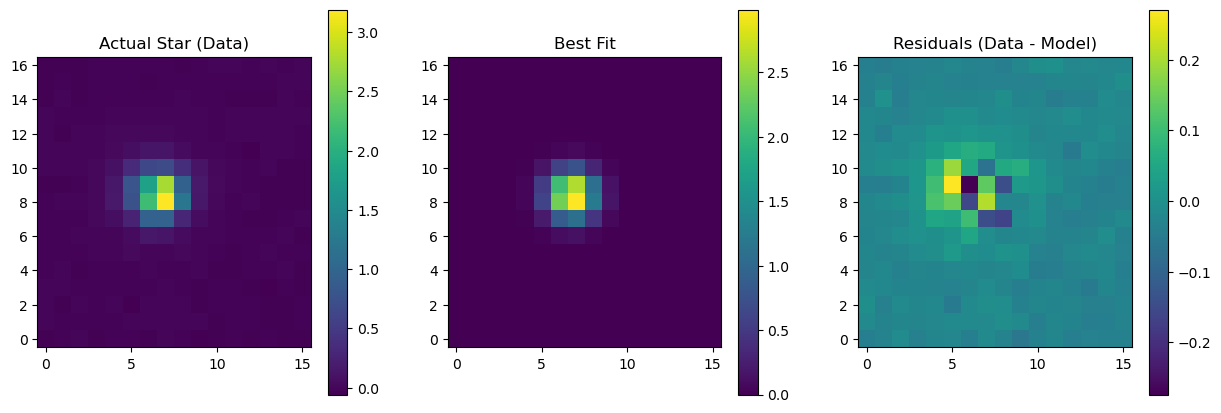

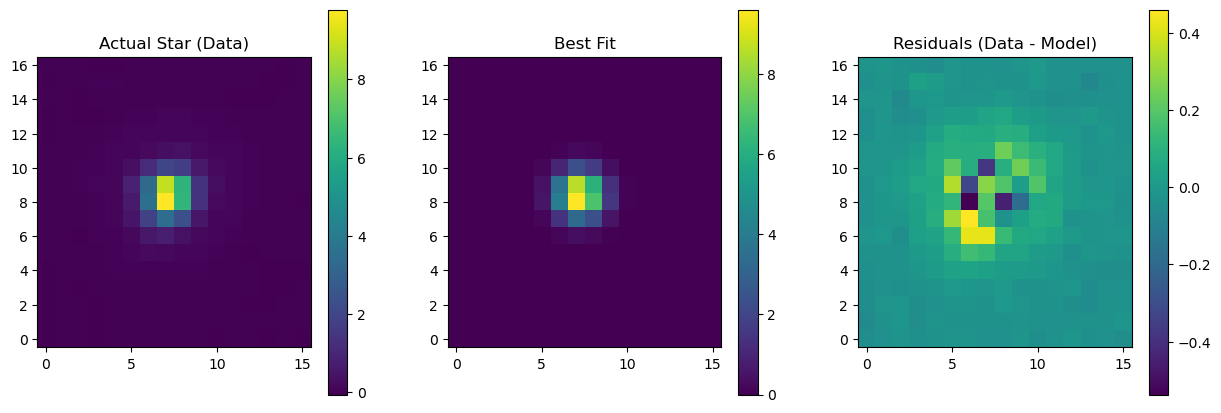

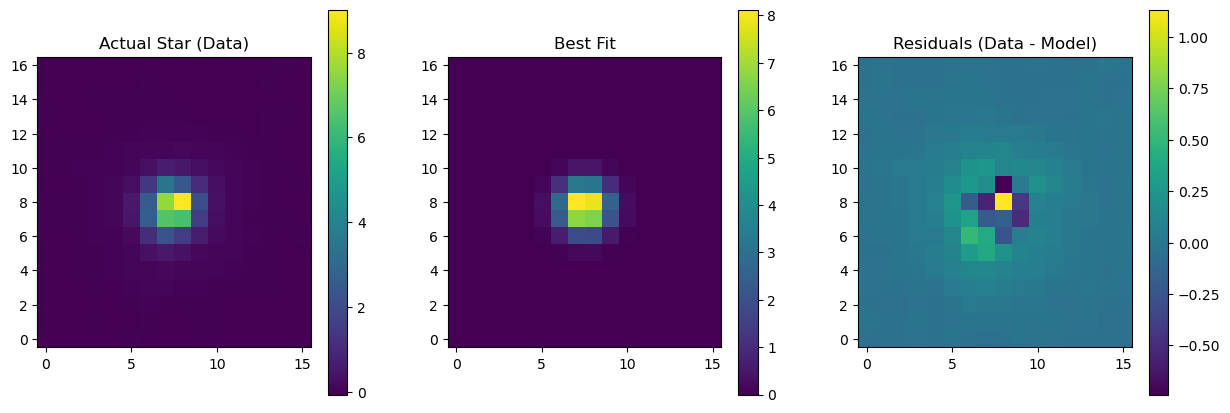

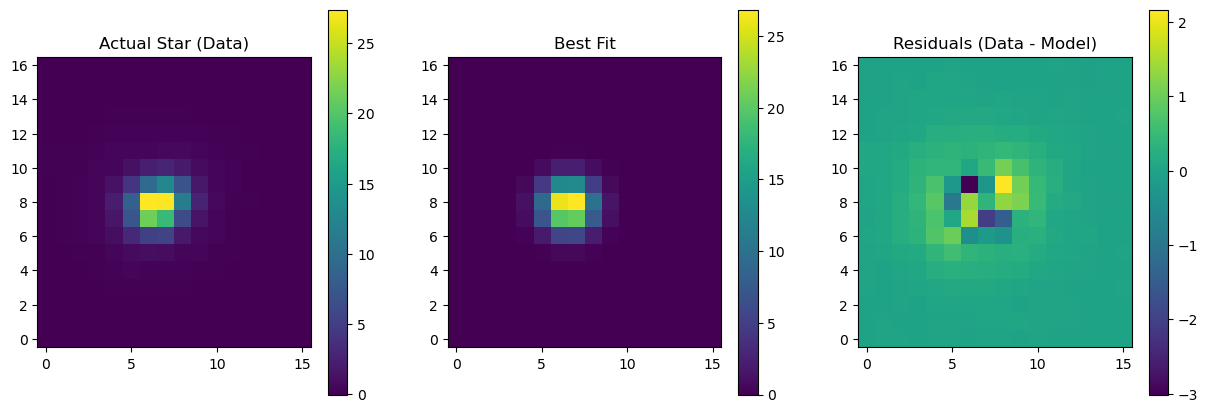

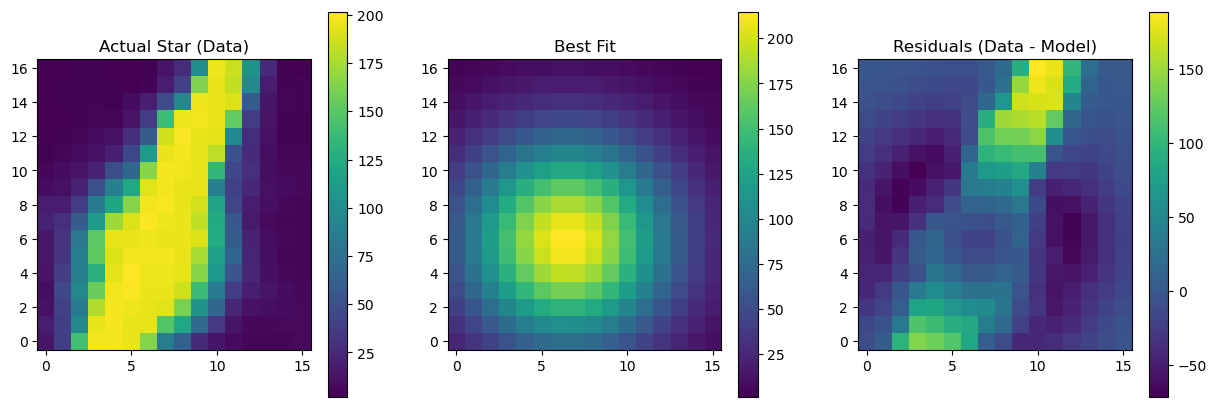

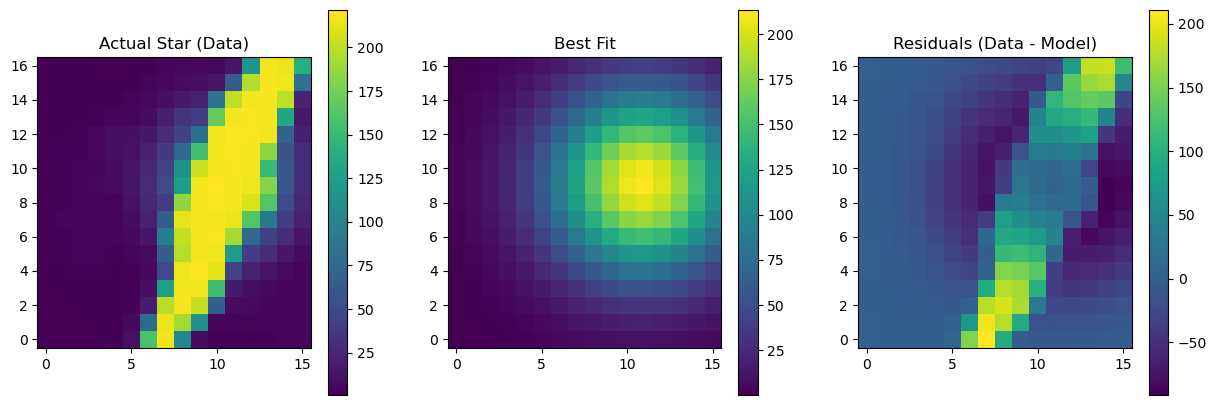

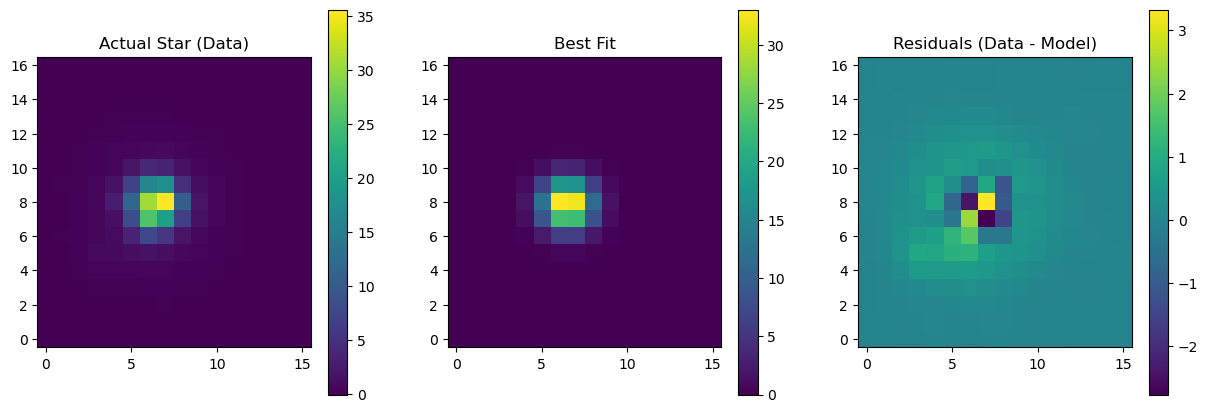

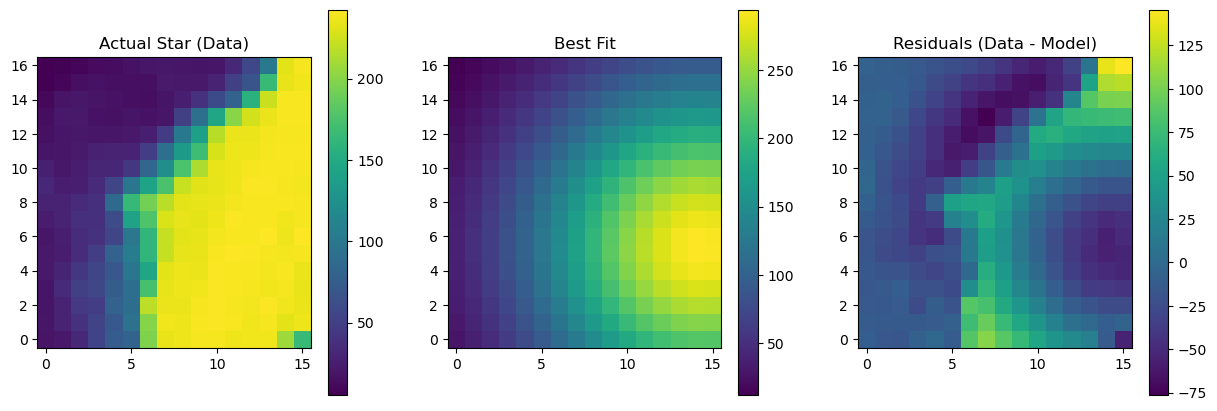

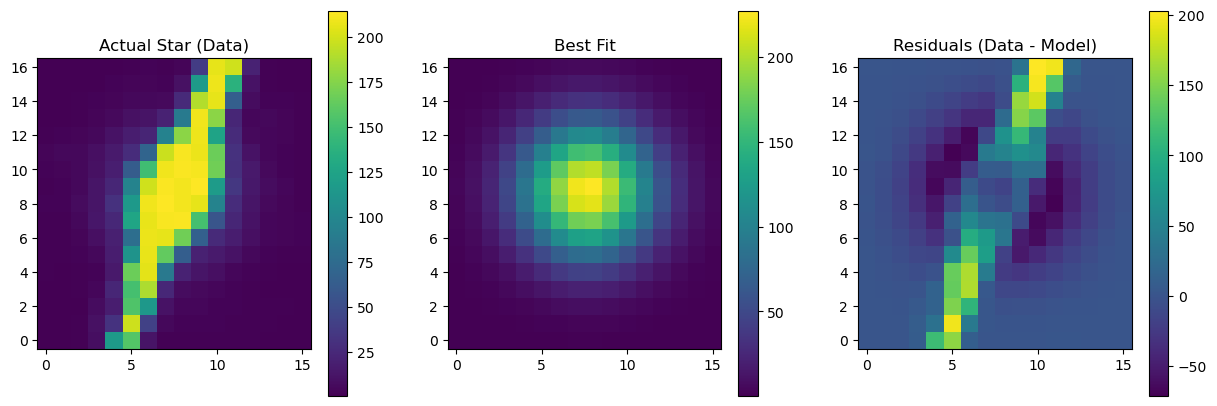

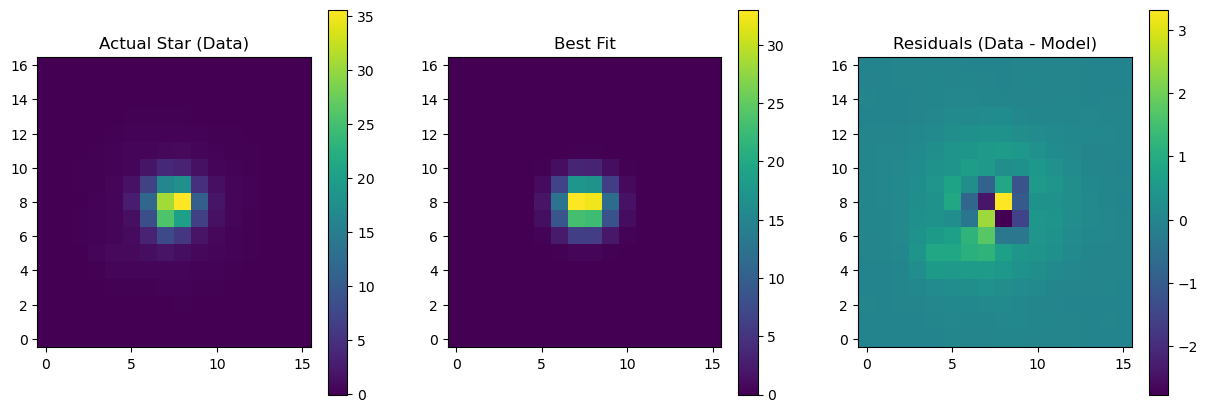

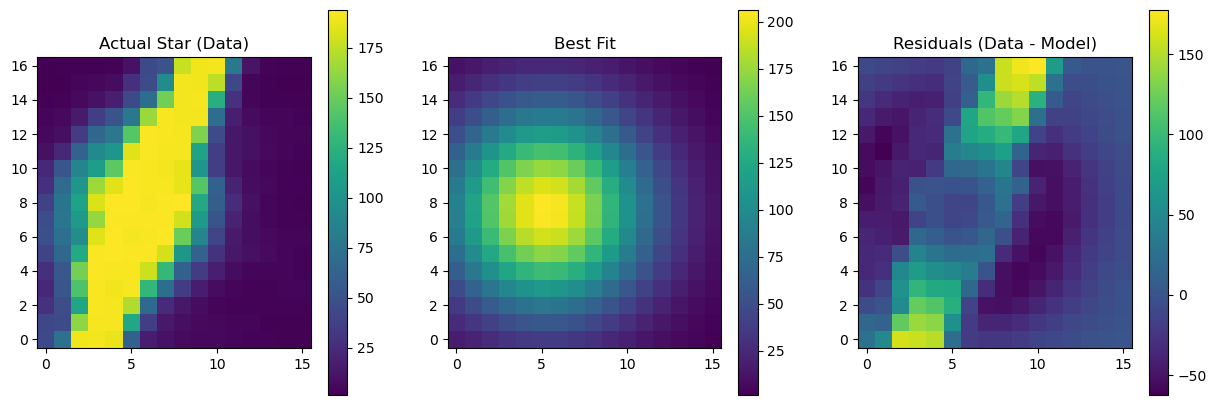

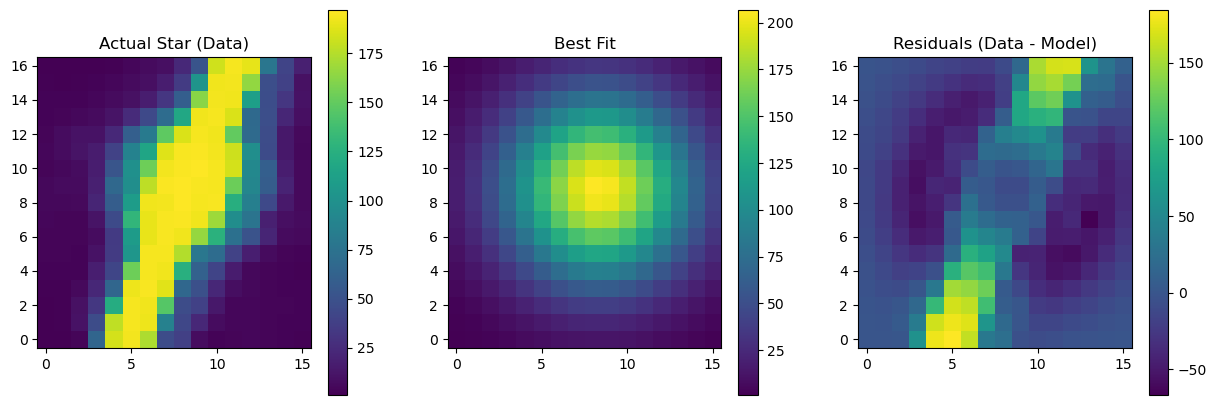

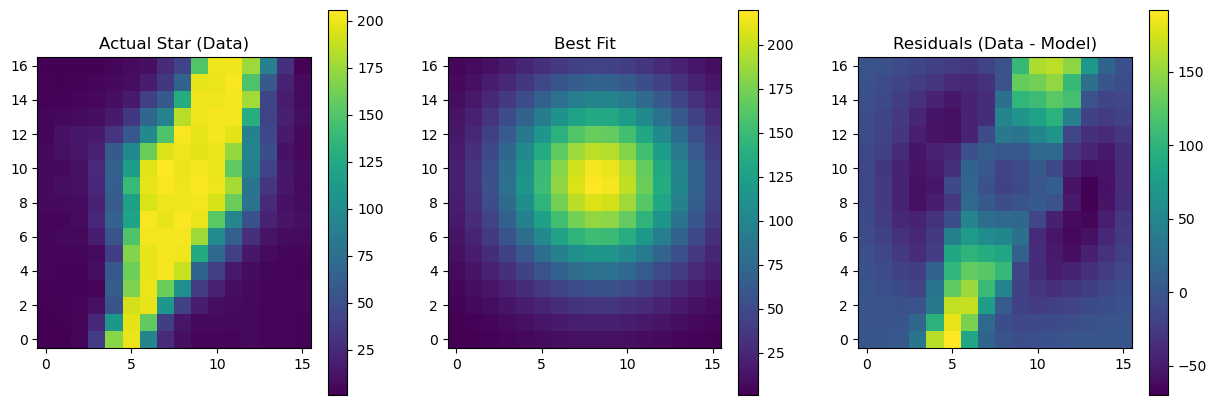

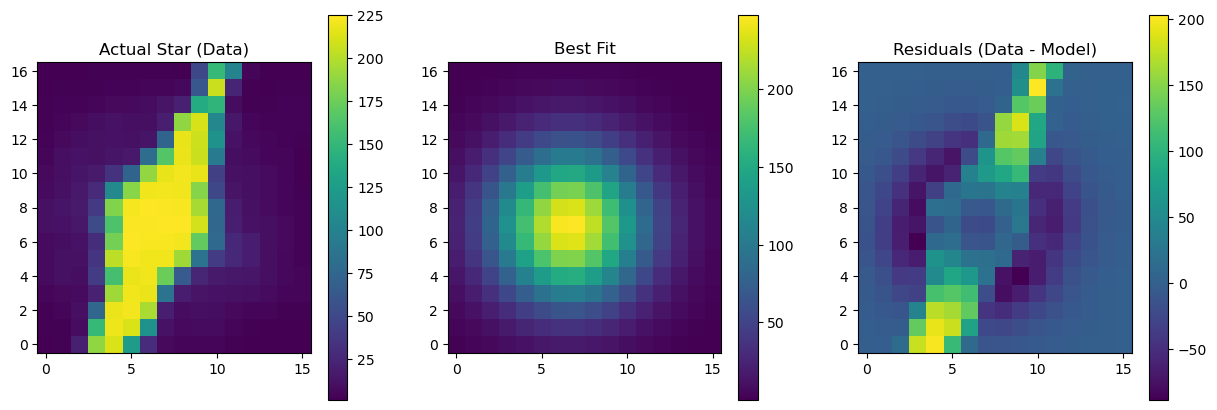

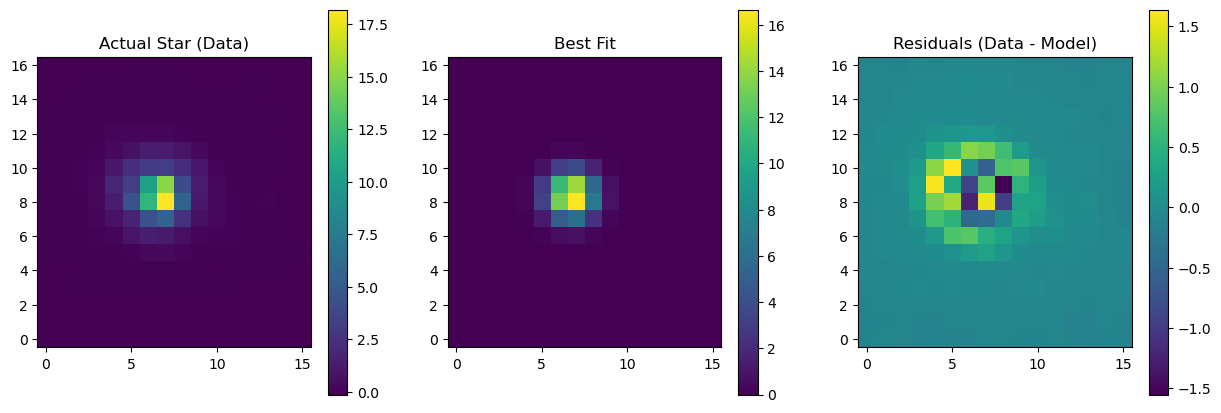

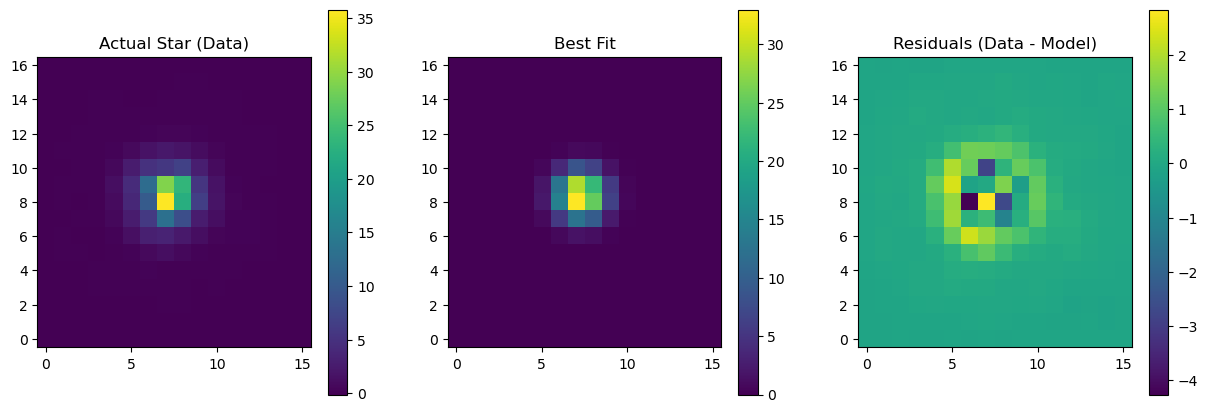

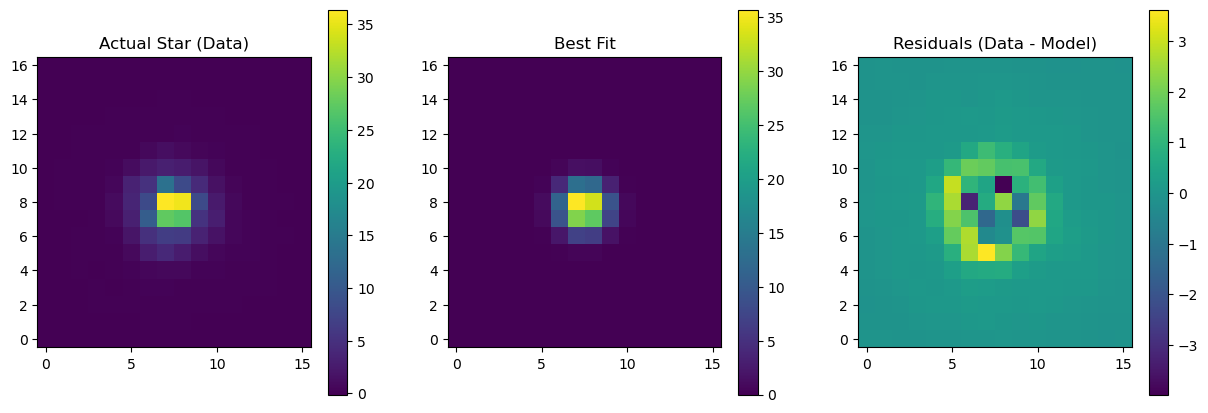

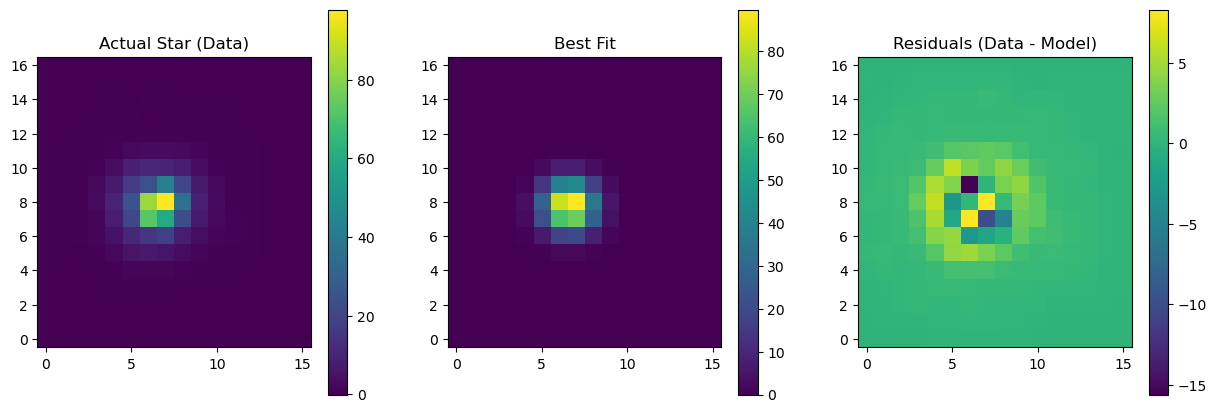

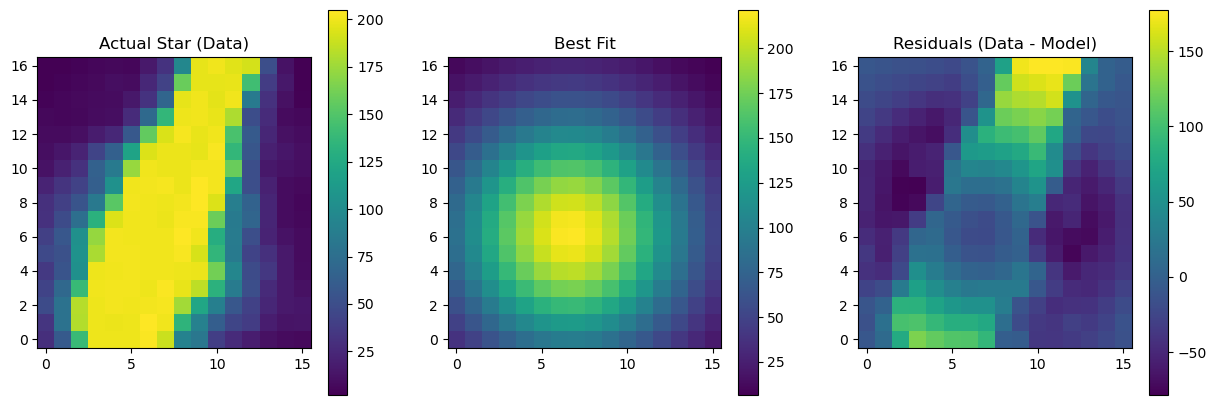

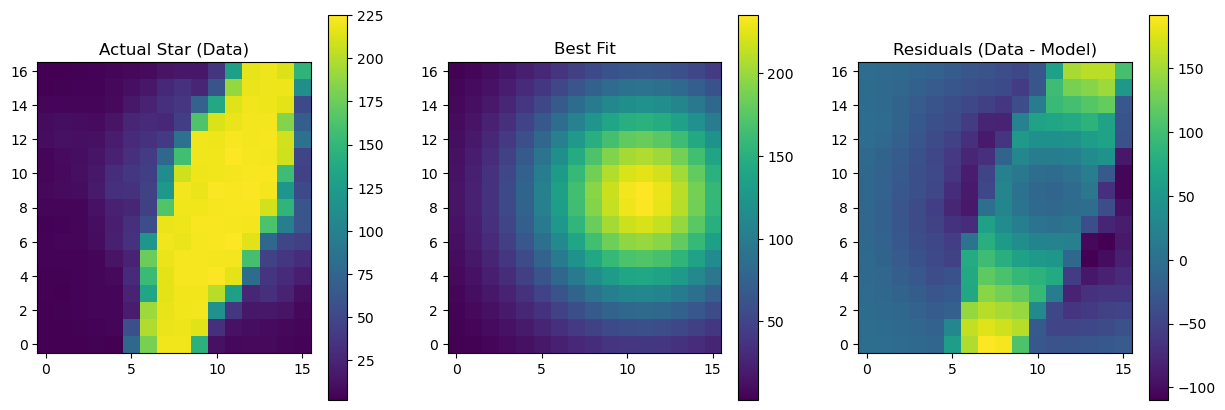

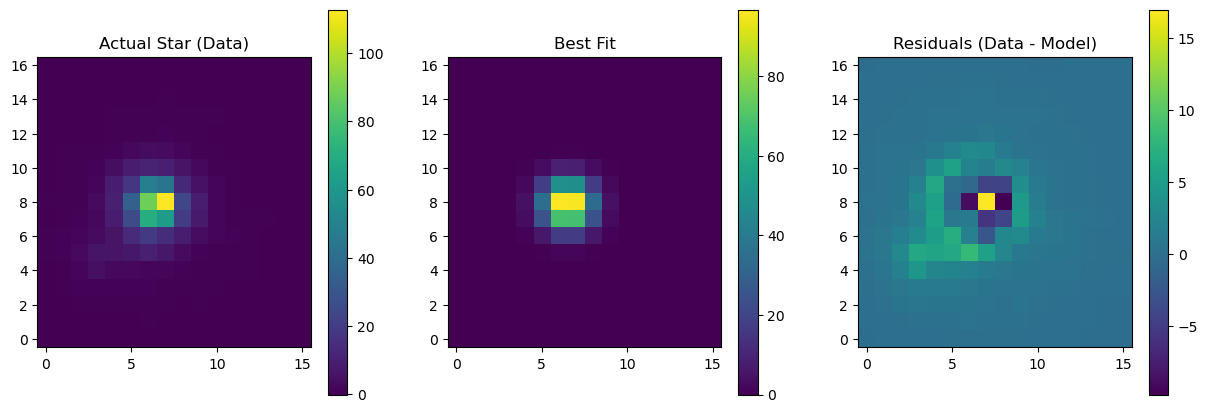

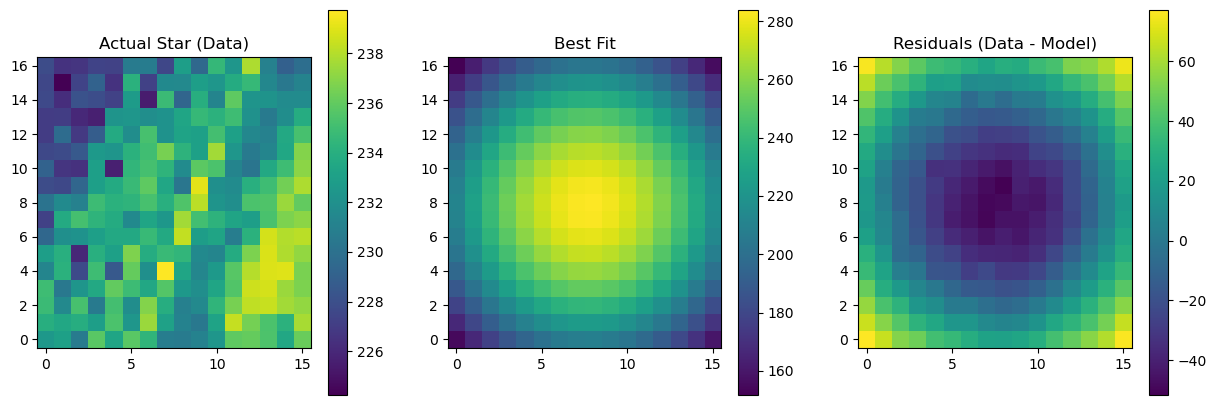

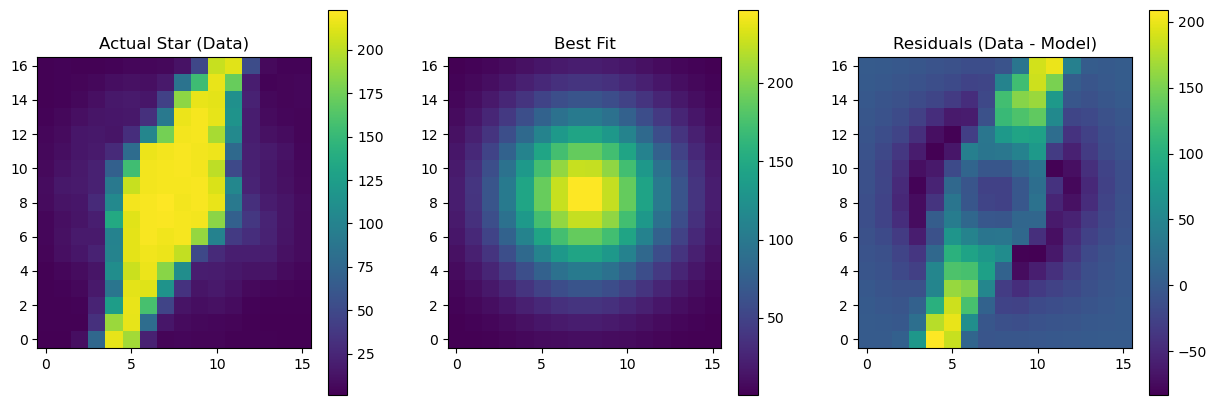

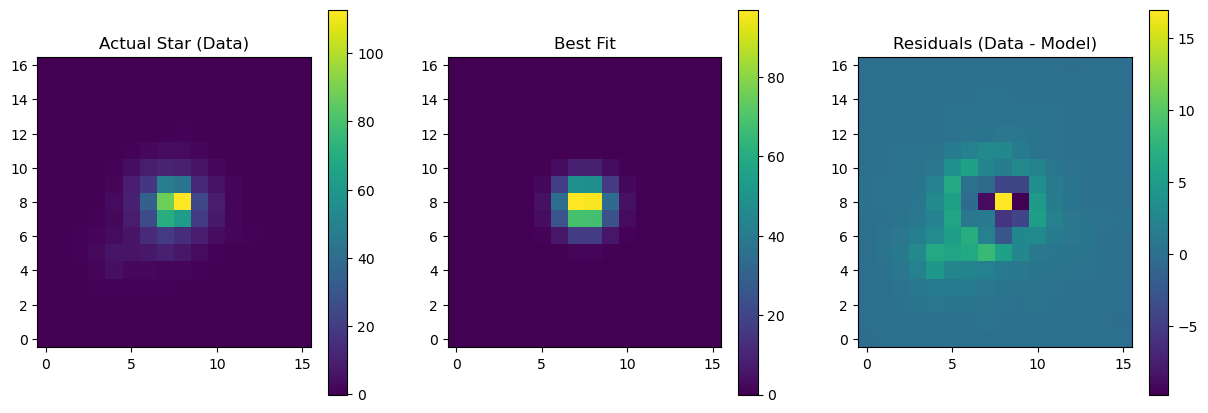

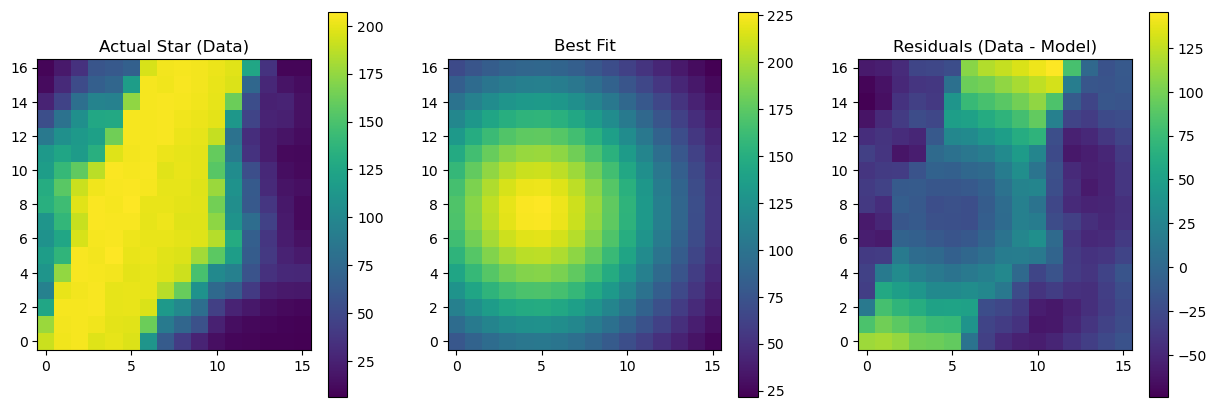

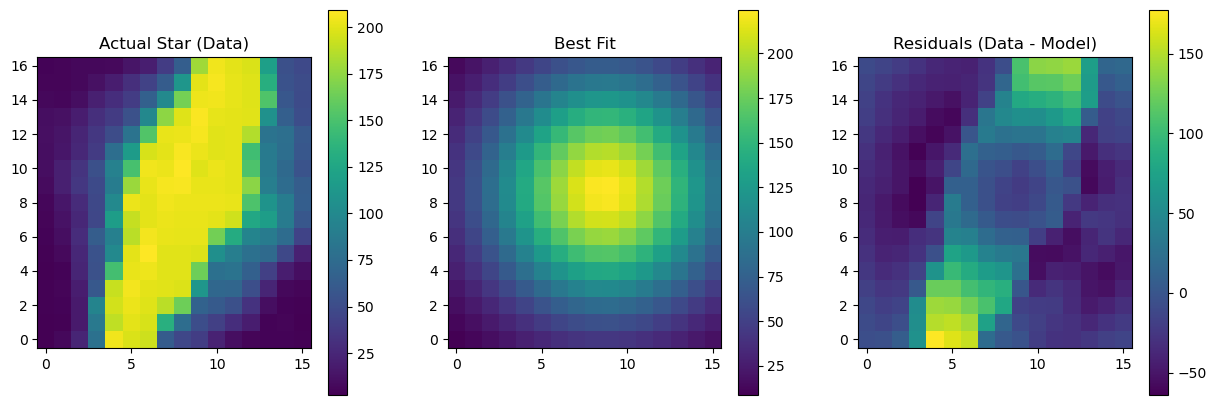

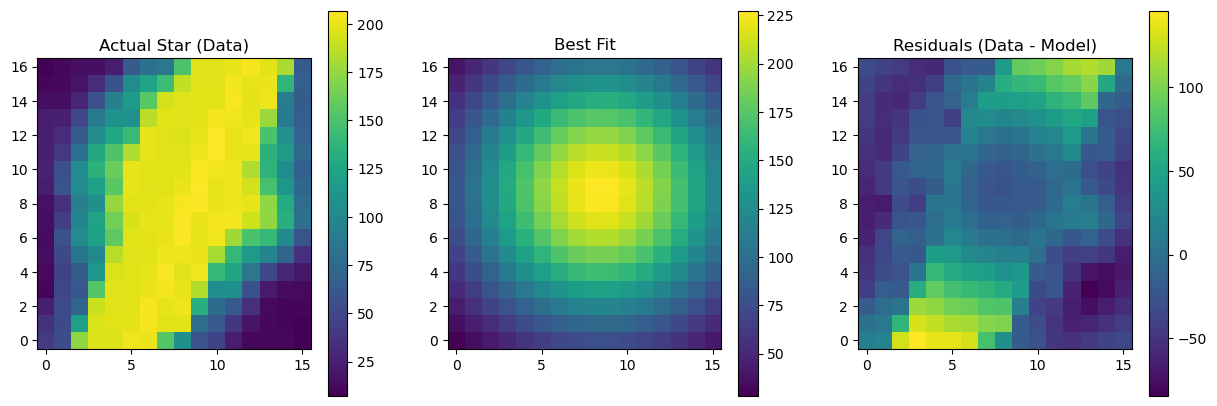

In [ ]:

flux = []

def psf_fit(coords, row, col, sigma=3, amplitude_func=100, offset=0):
    x, y = coords
    

    psf = amplitude_func * np.exp(-((y-row)**2 + (x-col)**2)/(2*sigma**2))
    fwhm = 2.355*sigma
    return psf.ravel()

def image_2660(selected_image):
    for s in stars:
        cutout = s.cutout(image=selected_image)
        y_size, x_size = cutout.shape
        yy, xx = np.meshgrid(np.arange(y_size), np.arange(x_size), indexing='ij') 
        xdata = (yy, xx)
        ydata = cutout.ravel()
        print(ydata.shape)
        ydata = np.nan_to_num(ydata, nan=np.nanmedian(ydata))
        peak = np.max(ydata)
        bg = np.median(ydata)
        flux.append(2 * np.pi * peak * 2**2)

        lower_bounds = [0, 0, 0.5, 0, -np.inf]
        upper_bounds = [y_size, x_size, 10.0, np.inf, np.inf]
        
        p0 = [
        y_size / 2,
        x_size / 2,
        1.0,
        peak - bg,
        bg
        ]
        print(p0)
        popt, pcov = optimize.curve_fit(
            psf_fit,
            xdata,
            ydata,
            p0=p0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=2000
        )
        fit_model = psf_fit(xdata, *popt).reshape(y_size, x_size)
        actual_data = ydata.reshape(y_size, x_size)
        fig, ax = plt.subplots(1, 3, figsize=(15, 5))

        im0 = ax[0].imshow(actual_data, origin='lower')
        ax[0].set_title('Actual Star (Data)')
        fig.colorbar(im0, ax=ax[0])
        
        im1 = ax[1].imshow(fit_model, origin='lower')
        ax[1].set_title('Best Fit')
        fig.colorbar(im1, ax=ax[1])
        
        im2 = ax[2].imshow(actual_data - fit_model, origin='lower')
        ax[2].set_title('Residuals (Data - Model)')
        fig.colorbar(im2, ax=ax[2]) 
        print(f"popt {popt}")
image_2660(subtracted_image_555)
image_2660(subtracted_image_814)
print(f"flux {flux}")

flux_555 [5266.194      80.236084  246.13202   226.5246    688.84985  5062.9644
 5565.3105    895.65576  6092.4434   5387.8237    895.65576  4872.5635
 4952.0356   5169.1304  ]
flux_814 [5655.5566   457.66074  900.6031   915.0482  2460.4385  5151.44
 5656.491   2834.2292  6025.603   5603.888   2834.2292  5208.326
 5260.482   5194.0996 ]
flux_subtraction [ 389.3628    377.42465   654.47107   688.5236   1771.5886     88.475586
   91.180664 1938.5735    -66.84033   216.06445  1938.5735    335.7627
  308.4463     24.969238]


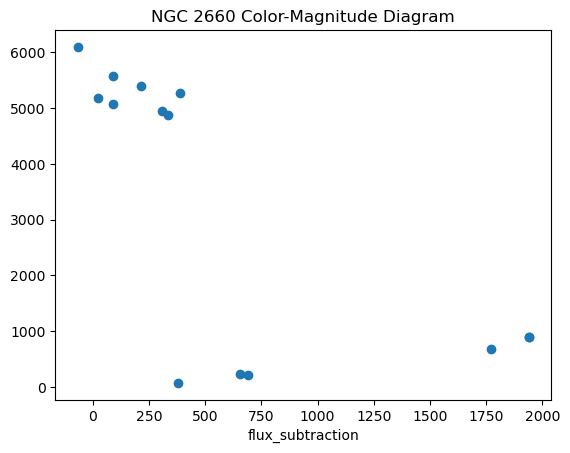

In [ ]:
#im pretty sure the 555 is the first set of data but not sure
flux_split = len(flux)//2 
intensity_555 = flux[:flux_split]
intensity_814 = flux[flux_split:]
print(f"flux_555 {intensity_555}")
print(f"flux_814 {intensity_814}")
flux_subtraction = intensity_814 - intensity_555
print(f"flux_subtraction {flux_subtraction}")

plt.scatter(flux_subtraction, intensity_555)
plt.xlabel("flux_subtraction")
plt.title("NGC 2660 Color-Magnitude Diagram")
plt.show()
